# 68 - EMNIST Letters: a harder classification problem

**Section:** CNNs | **Prereqs:** `CNNs/CNN_MNIST_ROLLED.ipynb` | **Next:** `CNNs/CNN_CIFAR_100.ipynb`

26 handwritten letters instead of 10 digits, and genuinely harder: more classes,
and several pairs (i/l, o/O, q/g, u/v) that are ambiguous even to a human reading
a single character with no word around it.

**Three things introduced here**

1. **The full modern conv block:** `Conv -> BatchNorm -> Activation -> Pool`.
   BatchNorm goes *after* the convolution and *before* the activation, and the
   conv layer's bias is then redundant (`bias=False` is the convention).
   `BatchNorm2d(C)` takes the channel count and normalises each channel across the
   batch and both spatial dimensions.

2. **Serious augmentation:** `RandomAffine` with rotation, translation, scale and
   shear - all label-preserving for handwriting, and shear in particular mimics
   the natural slant variation between writers.

3. **`Normalize((0.1307,), (0.3081,))`** - the MNIST mean and standard deviation.
   Normalising with dataset statistics rather than a plain 0-1 scale gives inputs
   centred on zero, which is what the layers downstream expect.

**The EMNIST orientation quirk:** torchvision returns the images rotated 90
degrees and mirrored. The `correct_emnist_orientation` transform undoes it. Always
*look* at a few samples from a new dataset before training - this is exactly the
kind of thing you catch in one glance and never from a loss curve.

| Step | Flatten → Linear | AdaptiveAvgPool2d → Linear |
|------|------------------|---------------------------|
| **Input** | `(B, 512, H, W)` | `(B, 512, H, W)` |
| **Operation** | `nn.Flatten()` | `nn.AdaptiveAvgPool2d((1,1))` |
| **After op** | `(B, 512×H×W)` | `(B, 512, 1, 1)` |
| **Reshape** | — | → `(B, 512)` |
| **Classifier** | `nn.Linear(512×H×W, 1000)` | `nn.Linear(512, 1000)` |
| **Output** | `(B, 1000)` | `(B, 1000)` |
| **Params** | 🔴 ~25M | 🟢 ~512K |
| **Input size** | 🔴 fixed | 🟢 any H,W |


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset

import torchvision
import torchvision.transforms as T
from torchsummary import summary

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
# EMNIST 'letters' split: 26 balanced classes, ~145k characters.
train_data = torchvision.datasets.EMNIST(root='/',split='letters', train=True, download=True)
test_data = torchvision.datasets.EMNIST(root='/',split='letters', train=False, download=True)

In [23]:
data = train_data.data
labels = train_data.targets

val_data = test_data.data
val_labels = test_data.targets

In [24]:
# Drop the placeholder class 0 ('N/A'), leaving 26 real letters.
# The labels are shifted by -1 below to match, since CrossEntropyLoss needs
# class indices in [0, 25].
categories = train_data.classes
categories = categories[1:]


In [25]:
len(categories)

26

In [26]:
val_data.shape

torch.Size([20800, 28, 28])

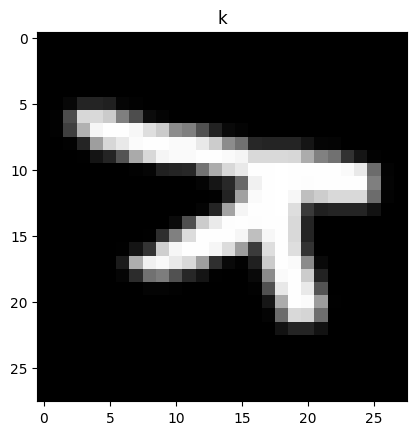

In [27]:
# Look at a sample before trusting anything. This is where the sideways,
# mirrored orientation becomes obvious.
plt.imshow(val_data[8000], cmap='gray')
plt.title(f"{categories[val_labels[8000] - 1]}");

#### NOTE : WE ARE SUBTRACTING 1 BECAUSE WE HAD 27 CLASSES BEFORE AND NOW ONLY 26.. SINCE PYTORCH IS GOING TO CONVERT THEM TO ONE HOT ENCODING, WE REMOVED THE REDUNDANT CLASS 'N/A' AND SUBTRACTED ALL LABELS BY ONE.


In [28]:
TensorDataset??

In [29]:
# The custom Dataset, as before.
class CustomDataset(Dataset):
    r"""Dataset wrapping tensors.

    Each sample will be retrieved by indexing tensors along the first dimension.

    Args:
        *tensors (Tensor): tensors that have the same size of the first dimension.
    """

    def __init__(self, tensors, custom_transforms=None) -> None:
        if any(tensors[0].size(0) != tensor.size(0) for tensor in tensors):
            raise AssertionError("Size mismatch between tensors")
        self.tensors = tensors
        self.transforms = custom_transforms

    def __getitem__(self, index):
        # Only Transform if needed.
      if self.transforms:
        X = self.transforms(self.tensors[0][index])
      else :
        X =  self.tensors[0][index]

      Y = self.tensors[1][index]
      return X,Y

    def __len__(self) -> int:
        return self.tensors[0].size(0)

In [30]:
# The transform pipelines.
# T.Lambda wraps any function into a transform - here to undo EMNIST's rotation
# and flip.
# RandomAffine applies rotation, translation, scaling and shear, all of which
# preserve the letter's identity - the test any augmentation must pass.
# Normalize uses MNIST's mean/std, so inputs are centred on zero rather than
# sitting in [0,1].
# Augmentation on train only; the test pipeline just fixes orientation.
def correct_emnist_orientation(img):
    """Fixes the default 90° rotation + horizontal flip in torchvision EMNIST."""
    img = T.functional.rotate(img, -90)
    img = T.functional.hflip(img)
    return img

train_transform = T.Compose([
    T.Lambda(correct_emnist_orientation),
    T.RandomAffine(
        degrees=15,           # Rotation ±15° (very effective for handwriting)
        translate=(0.1, 0.1), # Small shifts
        scale=(0.9, 1.1),     # Slight scaling
        shear=10              # Shear helps with handwriting slant
    ),
    T.Normalize((0.1307,), (0.3081,))  # Works well for EMNIST (similar to MNIST)
])


test_transform = T.Compose([
    T.Lambda(correct_emnist_orientation),
    T.Normalize((0.1307,), (0.3081,))
])

In [31]:
# Labels shifted by -1 so the 26 classes are indices 0-25.
# .view(N,1,28,28) adds the channel axis Conv2d requires.
device = ('cuda' if torch.cuda.is_available() else 'cpu')

data_tensor = torch.tensor(data.numpy(), dtype=torch.float, device=device).view(data.shape[0],1,28,28)
label_tensor = torch.tensor(labels.numpy()-1, dtype=torch.long, device=device)

val_data_tensor = torch.tensor(val_data.numpy(), dtype=torch.float, device=device).view(val_data.shape[0],1,28,28)
val_label_tensor = torch.tensor(val_labels.numpy() -1, dtype=torch.long, device=device)

train_dataset = CustomDataset((data_tensor, label_tensor), custom_transforms=train_transform)
val_dataset = CustomDataset((val_data_tensor, val_label_tensor), custom_transforms=test_transform)

bs=128

train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset,batch_size=val_dataset.tensors[0].shape[0])

In [32]:
# Shape check on a validation batch.
a,b = next(iter(val_loader))
a.shape

torch.Size([20800, 1, 28, 28])

In [33]:
a,b = next(iter(train_loader))
a.shape, b.shape

(torch.Size([128, 1, 28, 28]), torch.Size([128]))

In [34]:
device

'cuda'

In [35]:
b

tensor([14, 15,  9, 10, 22, 22, 23, 12,  2, 21, 22, 15,  7,  8, 25,  3, 14, 19,
         2, 23, 24,  4, 16, 17, 17,  7,  9, 22, 18, 14, 24, 21,  0, 10, 18, 12,
        13, 18, 19, 23,  1, 17,  9, 23,  0, 22, 24, 21,  3, 22, 19, 19, 10, 21,
        23,  7, 13,  5,  9,  6, 17,  4,  3, 17, 15, 23,  2, 14, 11,  3, 17, 11,
        22,  8, 16,  1, 16, 10, 20,  9, 24,  6,  7,  5,  4,  4, 14,  2, 22, 19,
        25,  8,  6, 17,  6,  9, 20,  9, 19, 20, 12, 18,  4, 14, 15, 10, 10, 14,
         4, 17, 12, 21, 23,  5, 23, 25,  4, 22,  5,  4, 21,  5,  0, 23,  5,  6,
        25,  2], device='cuda:0')

## CNN Model

In [36]:
# The model, as one nn.Sequential.
# Structure per block: Conv -> BatchNorm2d -> LeakyReLU -> AvgPool.
# BatchNorm2d takes the CHANNEL count and normalises each channel across the
# batch and both spatial axes.
# nn.Flatten() then feeds Linear(128*7*7, 512) - that 6272 has to be computed by
# hand from the conv arithmetic, and it is why the markdown at the top argues for
# AdaptiveAvgPool2d instead: it removes the hand computation and cuts the
# parameter count by an order of magnitude.
# Dropout(0.4) sits between the two Linear layers, where most parameters are.
class EMNIST(nn.Module):
  def __init__(self) :
    super().__init__()
    '''
    Conv → BN → ReLU → Pool
    Raw features → normalize → activate → downsample
    (stable, standard, paper-recommended)
  '''

    self.layers = nn.Sequential(
        nn.Conv2d(1,64,kernel_size=3,padding=1,stride=1), # Ouput -> [64,28,28]
        nn.BatchNorm2d(64), # BatchNorm take input channels
        nn.LeakyReLU(),
        nn.AvgPool2d(2,2), # Output -> [64,14,14]

        nn.Conv2d(64,128, kernel_size=3, padding=1, stride=1), # Output -> [128,14,14]
        nn.BatchNorm2d(128),
        nn.LeakyReLU(),
        nn.AvgPool2d(2,2), # Output -> [128,7,7]

        nn.Flatten(),
        nn.Linear(128*7*7, 512),
        nn.ReLU(),
        nn.Dropout(p=0.4),
        nn.Linear(512,26)

    )

  def forward(self,x):
    return self.layers(x)

In [37]:
# Instantiate on the GPU.
test_model = EMNIST()
test_model.to(device)

EMNIST(
  (layers): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=6272, out_features=512, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=512, out_features=26, bias=True)
  )
)

In [38]:
# torchsummary - check the shapes and see how many parameters that big Linear
# layer costs.
summary(test_model, input_size=(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 28, 28]             640
       BatchNorm2d-2           [-1, 64, 28, 28]             128
         LeakyReLU-3           [-1, 64, 28, 28]               0
         AvgPool2d-4           [-1, 64, 14, 14]               0
            Conv2d-5          [-1, 128, 14, 14]          73,856
       BatchNorm2d-6          [-1, 128, 14, 14]             256
         LeakyReLU-7          [-1, 128, 14, 14]               0
         AvgPool2d-8            [-1, 128, 7, 7]               0
           Flatten-9                 [-1, 6272]               0
           Linear-10                  [-1, 512]       3,211,776
             ReLU-11                  [-1, 512]               0
          Dropout-12                  [-1, 512]               0
           Linear-13                   [-1, 26]          13,338
Total params: 3,299,994
Trainable param

In [39]:
# AdamW (not Adam) with weight_decay=0.05: AdamW applies the decay directly to
# the weights rather than through the gradient, which is what L2 actually means.
# Prefer AdamW whenever you want weight decay with an adaptive optimizer.
#
# On top of that, an L1 penalty is added to the loss by hand, normalised by the
# parameter count. So this model has dropout + weight decay + L1 + augmentation.
# Note the L1 sum runs over ALL parameters including biases and BatchNorm
# scales, which is not the textbook form - weights only is the usual choice.
def train_model():

  model = EMNIST().to(device)

  lossfunc = nn.CrossEntropyLoss()
  epochs = 50
  optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.05,
    betas=(0.9, 0.999)
)


  losses = []
  train_acc = []
  val_acc = []

  l1_lambda = 1e-4

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossfunc(yhat,y)

      # Calculate L1 norm and normalize by the number of parameters
      l1_norm = sum(p.abs().sum() for p in model.parameters())
      num_parameters = sum(p.numel() for p in model.parameters())
      loss = loss + l1_lambda * (l1_norm / num_parameters)

      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc = 100 * torch.mean( (torch.argmax(yhat, dim=1) == y).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(val_loader))
      X = X.to(device)
      Y = Y.to(device)
      val_acc.append( 100 * torch.mean( (torch.argmax(model(X), dim=1) == Y).float().detach().cpu()) )


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return model, losses, train_acc, val_acc

In [40]:
model, losses, train_acc, val_acc = train_model()

Epoch 0 | Loss : 1.0195 | Train Acc 69.59375 | Val Acc : 90.14422607421875
Epoch 10 | Loss : 0.2663 | Train Acc 91.22676086425781 | Val Acc : 94.40384674072266
Epoch 20 | Loss : 0.2245 | Train Acc 92.45913696289062 | Val Acc : 94.40384674072266
Epoch 30 | Loss : 0.2063 | Train Acc 93.01683044433594 | Val Acc : 94.77884674072266
Epoch 40 | Loss : 0.1933 | Train Acc 93.37820434570312 | Val Acc : 95.01441955566406
Epoch 49 | Loss : 0.1848 | Train Acc 93.6378173828125 | Val Acc : 95.09134674072266


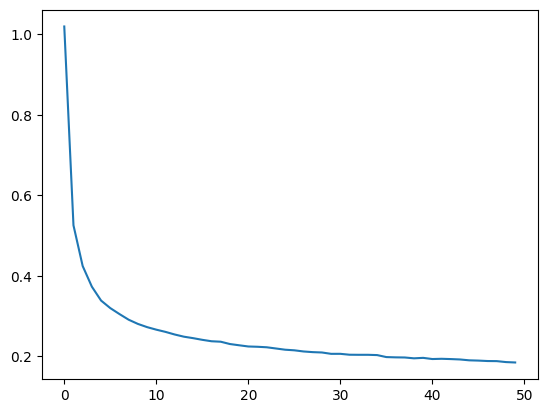

In [41]:
# Loss curve. It includes the L1 term, so its absolute value is not comparable
# to an unregularised run.
plt.plot(losses);

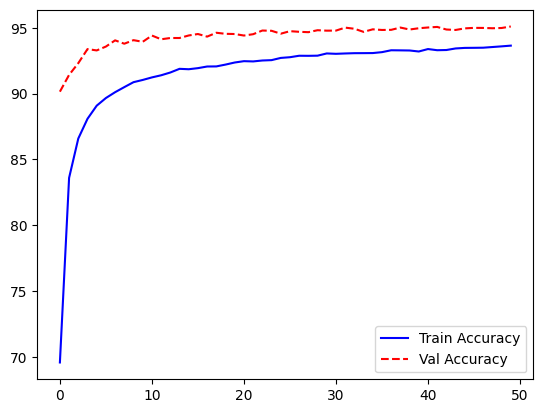

In [48]:
# Train vs validation accuracy. With this much regularisation train accuracy may
# sit BELOW validation - the training numbers are measured with dropout and
# augmentation active, and the validation numbers are not.
plt.plot(train_acc, 'b', label="Train Accuracy")
plt.plot(val_acc, 'r--', label="Val Accuracy")
plt.legend();

## TESTING

In [43]:
# Final evaluation. Note this reuses the validation loader, so it is a
# validation score rather than a held-out test score.
with torch.no_grad():
  model.eval()
  a, b = next(iter(val_loader))
  test_predictions = model(a.to(device))

  test_acc = 100 * torch.mean( (torch.argmax(test_predictions, dim=1) == b.to(device)).float().detach().cpu())


In [47]:
# The error rate (100 - accuracy). On 26 classes chance is 3.8%.
100 - test_acc

tensor(4.9087)

In [45]:
# Per-letter precision and recall. The interesting rows are the confusable
# pairs - i/l, q/g, u/v.
from sklearn.metrics import classification_report, confusion_matrix

preds = torch.argmax(test_predictions, dim=1).cpu().numpy()
true_labels = b.cpu().numpy()

print(classification_report(true_labels, preds, target_names=categories))

              precision    recall  f1-score   support

           a       0.95      0.96      0.96       800
           b       0.99      0.98      0.99       800
           c       0.97      0.98      0.97       800
           d       0.97      0.97      0.97       800
           e       0.98      0.98      0.98       800
           f       0.99      0.96      0.98       800
           g       0.90      0.88      0.89       800
           h       0.97      0.96      0.96       800
           i       0.76      0.77      0.76       800
           j       0.98      0.95      0.97       800
           k       0.98      0.98      0.98       800
           l       0.76      0.77      0.76       800
           m       0.99      0.99      0.99       800
           n       0.95      0.98      0.96       800
           o       0.97      0.97      0.97       800
           p       0.99      0.99      0.99       800
           q       0.89      0.88      0.88       800
           r       0.98    

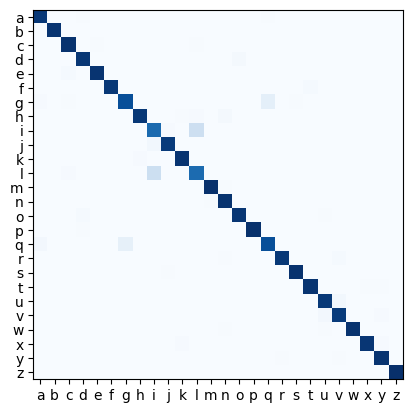

In [46]:
# The 26x26 confusion matrix. The bright off-diagonal cells name the pairs the
# model cannot separate, and most of them are pairs a human could not separate
# either from a single isolated character.
plt.imshow(confusion_matrix(true_labels, preds), cmap='Blues')
plt.xticks(range(26), categories)
plt.yticks(range(26), categories);